# Recall Probability by Lag

> Quantify the spacing effect: how recall improves with wider repetition spacing.

The spacing effect is a well-established memory phenomenon: repeated items benefit from wider spacing between presentations. Recall probability by lag (RPL) quantifies this by computing recall rate as a function of the number of intervening items between repeated presentations.

Two display modes are available: *binned* groups lags into coarse intervals (0, 1–2, 3–5, 6–8) for visualization, while *full* shows every lag bucket individually.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.rpl import (
    infer_max_lag,
    plot_full_rpl,
    plot_rpl,
    subject_binned_rpl,
    subject_full_rpl,
    run_rpl_slope_analysis,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [ ]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
mode = "full"
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
max_lag = infer_max_lag(data['pres_itemnos'], data['pres_itemnos'].shape[1])
plotting_function = plot_rpl if mode == "binned" else plot_full_rpl
subject_function = subject_binned_rpl if mode == "binned" else subject_full_rpl

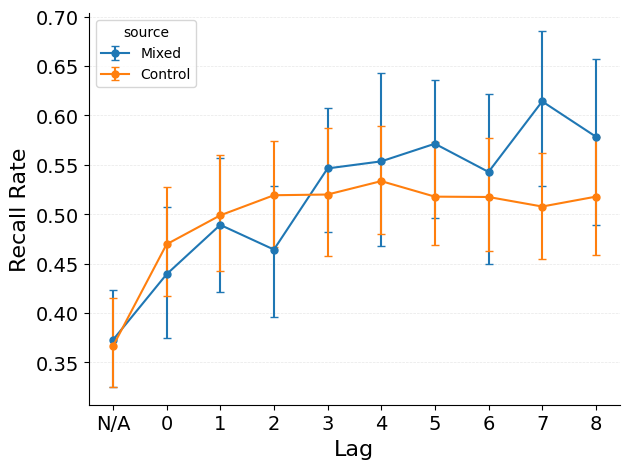

In [4]:
plotting_function(
    [data, control_dataset],
    [trial_mask, control_mask],
    labels=["Mixed", "Control"],
    contrast_name="source",
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

In [5]:
observed_result, control_result, comparison_result = run_rpl_slope_analysis(
    data, trial_mask, control_dataset, control_mask, mode=mode, max_lag=max_lag,
)

print("=" * 60)
print("Spacing Effect Slope: Observed")
print("=" * 60)
print(observed_result)

print("\n" + "=" * 60)
print("Spacing Effect Slope: Control")
print("=" * 60)
print(control_result)

print("\n" + "=" * 70)
print("Observed vs Control: Spacing Effect Slope")
print("=" * 70)
print(comparison_result)

Spacing Effect Slope: Observed
N=35
Mean slope: 0.0186
t-stat: 5.644 p=0.0000
W-stat: 65.0 p=0.0000

Spacing Effect Slope: Control
N=35
Mean slope: 0.0036
t-stat: 2.800 p=0.0084
W-stat: 148.0 p=0.0053

Observed vs Control: Spacing Effect Slope
N=35
Mean slope (observed): 0.0186
Mean slope (comparison): 0.0036
Mean difference: 0.0150
t-stat: 4.058 p=0.0003
W-stat: 105.0 p=0.0003


## Interpretation

The plot shows recall probability as a function of repetition spacing (number of intervening items) for both observed and control data. Key patterns:

- **Positive slope**: recall probability increases with wider spacing, demonstrating the spacing effect.
- **Observed > Control**: the spacing benefit exceeds what shuffled position assignments would produce.
- **Slope tests**: the statistical tests quantify whether the spacing slope is reliably positive and whether it differs between observed and control.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a list, or `None` for automatic scaling.
- `mixed_trial_query` — query selecting trials with repeated items.
- `control_trial_query` — query selecting trials for the control.
- `control_shuffles` — number of shuffle iterations for building the control dataset.
- `mode` — `"binned"` for coarse lag groups or `"full"` for individual lag buckets.
- `confidence_level` — confidence level for subject-wise error bars.